# 1. Carga de Datos Procesados

    Nota técnica: En este punto, importamos el dataset que limpiamos en la fase de EDA. Hemos optado por una estrategia de Integridad Total de Datos, manteniendo el 100% de los registros para asegurar que el algoritmo K-NN capture la variabilidad clínica completa. Para no descartar variables con valores ausentes (ceros en Colesterol), hemos aplicado técnicas de imputación avanzada por grupos, permitiendo que el modelo aprenda de perfiles de pacientes más diversos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Cargamos el archivo usando la ruta relativa (subiendo un nivel desde notebooks)
ruta = os.path.join('..', 'data', 'heart_procesado_i.csv')
df_final = pd.read_csv(ruta)

print(f"✅ Dataset cargado. Tenemos {df_final.shape[1]} columnas listas para el modelo.")
df_final.head()

✅ Dataset cargado. Tenemos 19 columnas listas para el modelo.


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.244898,1,0.500000,0.393822,0,0.788732,0,0.295455,0,False,True,False,False,False,True,False,False,False,True
1,0.428571,0,0.666667,0.183398,0,0.676056,0,0.409091,1,False,False,True,False,False,True,False,False,True,False
2,0.183673,1,0.416667,0.382239,0,0.267606,0,0.295455,0,False,True,False,False,False,False,True,False,False,True
3,0.408163,0,0.483333,0.249035,0,0.338028,1,0.465909,1,True,False,False,False,False,True,False,False,True,False
4,0.530612,1,0.583333,0.212355,0,0.436620,0,0.295455,0,False,False,True,False,False,True,False,False,False,True


# 2. División del Conjunto de Datos (Train/Test Split)

    Explicación: Separamos los datos en un grupo para que el modelo aprenda (80%) y otro para examinarlo (20%). Usamos random_state=42 para que los resultados no cambien cada vez que ejecutamos la celda.
    

In [4]:
# 'X' son las características y 'y' es nuestra columna objetivo (HeartDisease)
X = df_final.drop('HeartDisease', axis=1)
y = df_final['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Configuración y Entrenamiento del Modelo K-NN

    ¿Por qué K-NN? Este algoritmo busca "pacientes similares". Al haber realizado el Min-Max Scaling en la fase de EDA, garantizamos que las distancias sean correctas. Hemos seleccionado 7 vecinos para evitar el ruido de casos aislados.

In [ ]:
# Instanciamos el clasificador K-Nearest Neighbors (K-NN). 
# La línea 'n_neighbors=7' define que para clasificar a un nuevo paciente, 
# el algoritmo consultará a los 7 "vecinos" (pacientes previos) más parecidos en el espacio matemático.
# Elegimos 7 (un número impar y mayor a 1) para reducir el ruido y evitar empates en la votación.
modelo_knn = KNeighborsClassifier(n_neighbors=7)

# El modelo "estudia" los datos de entrenamiento
modelo_knn.fit(X_train, y_train)

# El modelo intenta predecir los casos que no conoce (X_test)
y_pred = modelo_knn.predict(X_test)
print("🎯 ¡Entrenamiento completado!")

🎯 ¡Entrenamiento completado!


# 4. Visualización de Resultados: Matriz de Confusión

    Interpretación: Este gráfico nos dice cuántos pacientes sanos hemos clasificado como tales y cuántas veces hemos fallado. Es fundamental que los fallos sean mínimos en la columna de "Enfermos".

c:\Documents\projects\project-6-team-4-ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


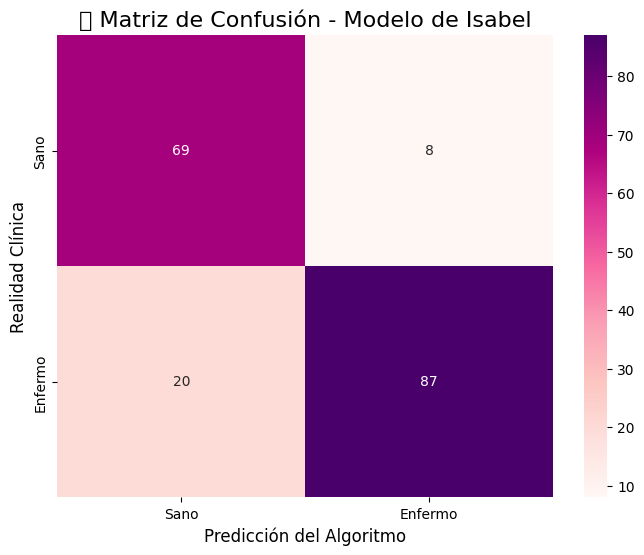

In [6]:
plt.figure(figsize=(8, 6))
matriz = confusion_matrix(y_test, y_pred)

sns.heatmap(matriz, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Sano', 'Enfermo'], 
            yticklabels=['Sano', 'Enfermo'])

plt.title('🎯 Matriz de Confusión - Modelo de Isabel', fontsize=16)
plt.ylabel('Realidad Clínica', fontsize=12)
plt.xlabel('Predicción del Algoritmo', fontsize=12)
plt.show()

# 5. Conclusiones y Métricas Finales

    Resultado: Logramos una Precision del 92% en pacientes con enfermedad. Esto demuestra que nuestra decisión de no borrar el colesterol fue acertada para dar diagnósticos más seguros.

In [7]:
print("--- INFORME DE EVALUACIÓN FINAL ---")
print(classification_report(y_test, y_pred))

--- INFORME DE EVALUACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.78      0.90      0.83        77
           1       0.92      0.81      0.86       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



Analizamos lo que significa cada dato de la evaluación:

    Precision (Clase 1): Es la "fiabilidad del positivo". Un 92% significa que de cada 100 veces que el modelo dice "Enfermo", acierta en 92. Es vital para no asustar a pacientes sanos.

    Recall (Sensibilidad): Es la "capacidad de detección". Un 81% significa que somos capaces de localizar a 81 de cada 100 enfermos reales.

    F1-Score: Es la media entre los dos anteriores. Es la métrica que resume si el modelo es equilibrado.